<a href="https://colab.research.google.com/github/annieannie12345/cnn-cat-dog-classifierr/blob/main/cnn_cat_dog_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_set_catvdog.zip to data_set_catvdog.zip


In [64]:
import zipfile
import os

zip_path = "data_set_catvdog.zip"   # apni file ka naam check kar lena
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [65]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D,MaxPooling2D, Flatten, BatchNormalization, Dropout    #, BatchNormalization, Dropout #using batchnormalization to reduce overfitting

In [66]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data_set_catvdog/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/data_set_catvdog/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 2101 files belonging to 2 classes.
Found 300 files belonging to 2 classes.


In [67]:
# Normalize
def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# create CNN model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())                                                   # model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())                                                   #model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())                                                   #model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))                                                           #model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))                                                           #model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [70]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [73]:
import tensorflow as tf

history = model.fit(
    train_ds.ignore_errors(),
    epochs=32,
    validation_data=validation_ds.ignore_errors()
)

Epoch 1/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9928 - loss: 0.0239 - val_accuracy: 0.7367 - val_loss: 1.8906
Epoch 2/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.9920 - loss: 0.0145 - val_accuracy: 0.7433 - val_loss: 1.8140
Epoch 3/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.9975 - loss: 0.0093 - val_accuracy: 0.7533 - val_loss: 1.9349
Epoch 4/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9991 - loss: 0.0055 - val_accuracy: 0.7267 - val_loss: 1.6502
Epoch 5/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.9955 - loss: 0.0117 - val_accuracy: 0.7200 - val_loss: 1.8055
Epoch 6/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9931 - loss: 0.0329 - val_accuracy: 0.6800 - val_loss: 2.6425
Epoch 7/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9936 - loss: 0.0217 - val_accuracy: 0.7133 - val_loss: 2.1746
Epoch 8/32
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9931 - loss: 0.0107 - val_accuracy: 0.7100 - v

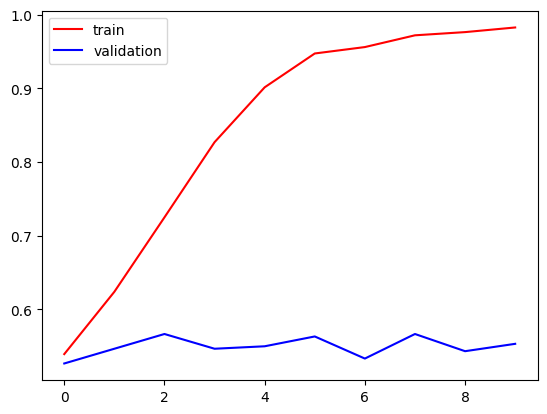

In [43]:
import matplotlib.pyplot as plt          #without batchnormalization and dropout

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')

plt.legend()
plt.show()

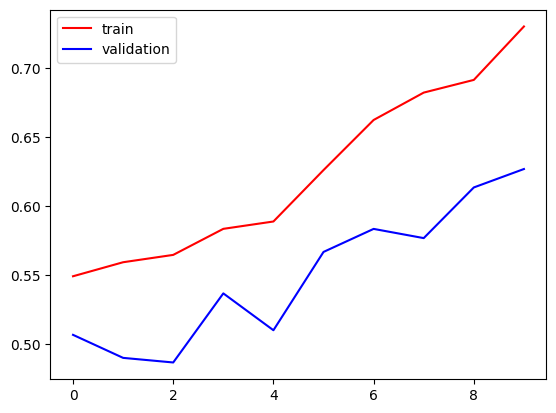

In [35]:
plt.plot(history.history['accuracy'], color='red', label='train') #with batchnormalization and dropout
plt.plot(history.history['val_accuracy'], color='blue', label='validation')

plt.legend()
plt.show()

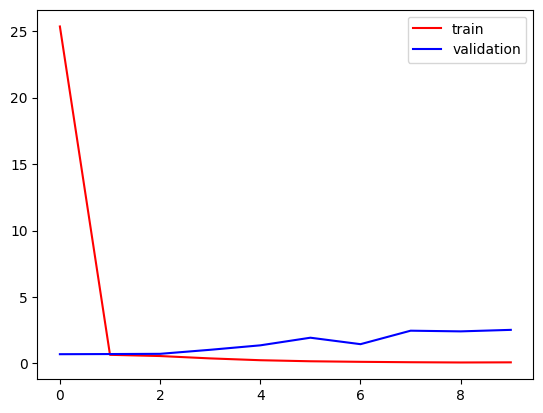

In [44]:
plt.plot(history.history['loss'], color='red', label='train')   #without batchnormalization and dropout
plt.plot(history.history['val_loss'], color='blue', label='validation')

plt.legend()
plt.show()

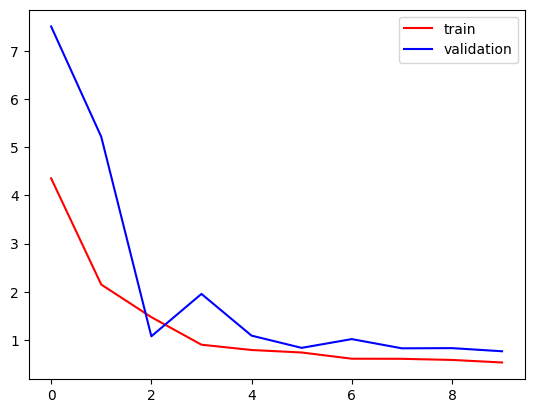

In [36]:
plt.plot(history.history['loss'], color='red', label='train')     #with batchnormalization and dropout
plt.plot(history.history['val_loss'], color='blue', label='validation')

plt.legend()
plt.show()

In [ ]:
# ways to reduce overfitting

# Add more data
# data Augmentation
# L1/L2 Regularizer
# Dropout
# Batch Normalization
# Reduce complexity

In [45]:
import cv2

In [59]:
test_image = cv2.imread('/content/2692.jpg') '''import zipfile

# paths
cat_zip = "/content/cat_pic.jpg.zip"
dog_zip = "/content/dog_pic.jpg.zip"

# extract location
extract_path = "/content/"

# unzip cat
with zipfile.ZipFile(cat_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# unzip dog
with zipfile.ZipFile(dog_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("cat and dog unzipped ")'''

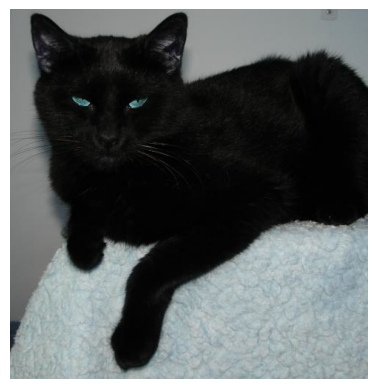

In [61]:
import cv2
import matplotlib.pyplot as plt

# Re-load the image correctly, assuming '2694.jpg' is the extracted dog image
test_image = cv2.imread('/content/2692.jpg')

if test_image is not None:
    plt.imshow(test_image)
    plt.axis('off') # Optional: turn off axes for cleaner image display
    plt.show()
else:
    print("Error: Could not load the image. Please check the file path and ensure it's a valid image file.")

In [62]:
import numpy as np

# Resize the image to the target size (256, 256) and normalize
img_resized = cv2.resize(test_image, (256, 256))
img_normalized = img_resized / 255.0

# Expand dimensions to match model input shape (batch_size, height, width, channels)
img_input = np.expand_dims(img_normalized, axis=0)

print("Image preprocessed and ready for prediction. Shape:", img_input.shape)

Image preprocessed and ready for prediction. Shape: (1, 256, 256, 3)


In [63]:
prediction = model.predict(img_input)

# Interpret the prediction
if prediction[0][0] > 0.5:
    print(f"Prediction: Dog (confidence: {prediction[0][0]:.2f})")
else:
    print(f"Prediction: Cat (confidence: {1 - prediction[0][0]:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction: Cat (confidence: 0.98)
